# 3. 읽을 수 있는 정보와 실제 쓰이는 정보

**출발 질문:** probe가 100% 맞히면 그 방향으로 activation을 바꿀 때 모델 출력도 바뀌어야 할까?
“정보가 있다 / 특정 readout이 가능하다 / 모델이 자연 실행에서 그것을 쓴다”를 분리한다.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():
    candidates = [HERE / "study/linear_probes_ko", HERE / "ARENA_3.0/study/linear_probes_ko"]
    HERE = next(p for p in candidates if (p / "probe_lab.py").exists())
sys.path.insert(0, str(HERE))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from probe_lab import (group_split_indices, fit_mean_difference, fit_logistic_probe,
                       score_metrics, fit_train_pca, group_bootstrap_ci)
np.set_printoptions(precision=3, suppress=True)

## 반례를 직접 만들기

모델 상태에 같은 정보를 두 번 저장하되 실제 출력은 두 번째 좌표만 읽게 만든다.
첫 좌표의 probe는 완벽하지만 그 좌표 개입은 아무 효과가 없다.
이 toy example은 Llama에 대한 관찰이 아니라 **논리적 함의가 성립하지 않음**을 보여 준다.

In [2]:
rng=np.random.default_rng(8)
y=np.tile([0,1],100); signal=2*y-1
H=np.c_[signal,signal+.2*rng.normal(size=len(y))]
probe_score=H[:,0]
model_output=lambda h: h[:,1]
changed=H.copy();changed[:,0]+=5
print("Probe accuracy:",np.mean((probe_score>0)==y))
print("첫 좌표 개입 출력 변화:",np.max(np.abs(model_output(changed)-model_output(H))))
changed[:,1]+=5
print("둘째 좌표 개입 출력 변화:",np.mean(model_output(changed)-model_output(H)))

Probe accuracy: 1.0
첫 좌표 개입 출력 변화: 0.0
둘째 좌표 개입 출력 변화: 5.0


## 세 종류의 개입을 혼동하지 않기

| 실험 | 실제 하는 일 | 바로 말할 수 있는 것 |
|---|---|---|
| Additive steering | h ← h + αd | 이 조작에 대한 출력 민감성 |
| Activation patching | 특정 site를 다른 실행의 activation으로 교체 | 지정된 source/target/site에서의 개입 효과 |
| 인과 매개 분석 | 명시한 causal model과 contrast에 따른 효과 추정 | 가정이 만족될 때의 매개 효과 |

원본의 `mm_nie/lr_nie`는 단순 score 변화다. 이 자료에서는 **additive intervention effect**라 부른다.
patching조차 off-distribution 상태나 사용되지 않던 경로를 만들 수 있다. 따라서 성공한 개입 하나가
자연 실행의 메커니즘을 유일하게 확정하지 않는다. 핵심 후속 반례는 `SOURCES_AND_CLAIMS.md` 참고.

## 실제 모델 pilot: 사전에 고정한 설계

- train cities의 block14에서 MM direction을 학습하고 unit norm으로 만든다.
- 같은 방향의 train projection 표준편차를 scale로 삼아 α ∈ {−2,−1,0,1,2}를 미리 정한다.
- held-out 6개 도시의 참/거짓 12문장을 고정한 few-shot True/False prompt에 넣는다.
- 마지막 `Answer:` token의 block14 출력에만 더한다. metric은 **True − False next-token logit**이다.
- unit norm random direction 하나와 α=0을 대조한다. hook은 항상 제거한다.
- 답변 token은 고립된 문자열 대신 전체 prompt+답변을 tokenize하여 한 token continuation인지 검증한다.

**이 설계의 약점도 미리 기록:** probe 학습 위치는 문장 끝, 개입 위치는 few-shot의 Answer:다.
효과 없음은 truth representation 부재와 동치가 아니다. 효과 있음도 바로 belief 변경은 아니다.
random direction 하나와 12문장은 탐색적 sanity check 수준이다.

,direction,alpha,mean_logit_shift,mean_true_logit_margin,n
0,MM,-2.0,-0.333333,-0.395833,12
1,MM,-1.0,-0.166667,-0.229167,12
2,MM,0.0,0.000000,-0.062500,12
3,MM,1.0,0.208333,0.145833,12
4,MM,2.0,0.479167,0.416667,12
5,random,-2.0,0.208333,0.145833,12
6,random,-1.0,0.062500,0.000000,12
7,random,0.0,0.000000,-0.062500,12
8,random,1.0,-0.093750,-0.156250,12
9,random,2.0,-0.239583,-0.302083,12


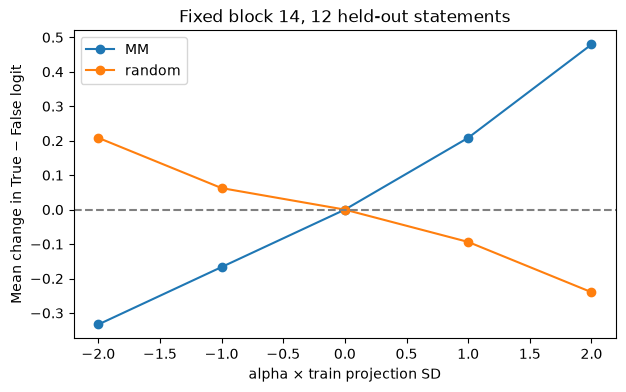

In [3]:
import json
r=json.loads((HERE/"artifacts/results.json").read_text())
effects=pd.DataFrame(r["intervention"])
display(effects)
fig,ax=plt.subplots(figsize=(7,4))
for name,part in effects.groupby("direction"):
    ax.plot(part.alpha,part.mean_logit_shift,"o-",label=name)
ax.axhline(0,color="gray",ls="--")
ax.set(xlabel="alpha × train projection SD",ylabel="Mean change in True − False logit",title="Fixed block 14, 12 held-out statements")
ax.legend();plt.show()

## 결과에 따라 결론을 다르게 쓰기

- MM 효과가 random보다 크면: 이 특정 prompt/site/scale에서 방향 선택이 출력 변화에 관련되어 있다.
- 둘 다 비슷하면: generic perturbation 가능성이 있어 특이성 근거가 약하다.
- 둘 다 작으면: 위치·맥락 불일치, model readout, BF16 작은 변화 등 대안 설명을 남긴다.
- 큰 α에서만 효과가 생기면: 자연 activation 범위를 벗어나는지 norm과 출력 품질을 확인한다.

**지금 하지 않은 검증:** 여러 random 방향 분포, 여러 prompt, source-consistent patching,
truth와 무관한 출력 손상 지표, per-label 효과, 독립 test replication.
이 모든 것을 당장 구현할 필요는 없다. 자신의 핵심 주장에 필요한 최소 다음 대조군 하나를 선택한다.

In [4]:
conclusion = {
    "observation":"",
    "allowed_claim":"",
    "overclaim_to_avoid":"",
    "most_informative_next_control":"",
}

<details><summary>구두 시험 — 설명할 수 있으면 다음으로</summary>

1. LR가 MM보다 분류를 잘하지만 steering은 약할 수 있는가? 그렇다. 예측 목적함수와 인과적 사용은 다르며 norm/좌표를 맞춰야 한다.
2. `w_scaled`를 raw residual에 더하면? 다른 방향을 조작하게 된다.
3. 음의 α에서 출력이 false로 이동하면 모델이 거짓말한 것인가? 아니다. 특정 출력 점수의 조작 결과이며 기만 의도 라벨이 없다.
4. α=0 비교가 다른 결과라면? dropout, hook 잔류, padding/site, nondeterminism부터 점검한다.

</details>

이제 04에서 truth label을 **instruction label·행동 label·high-stakes label**과 분리한다.